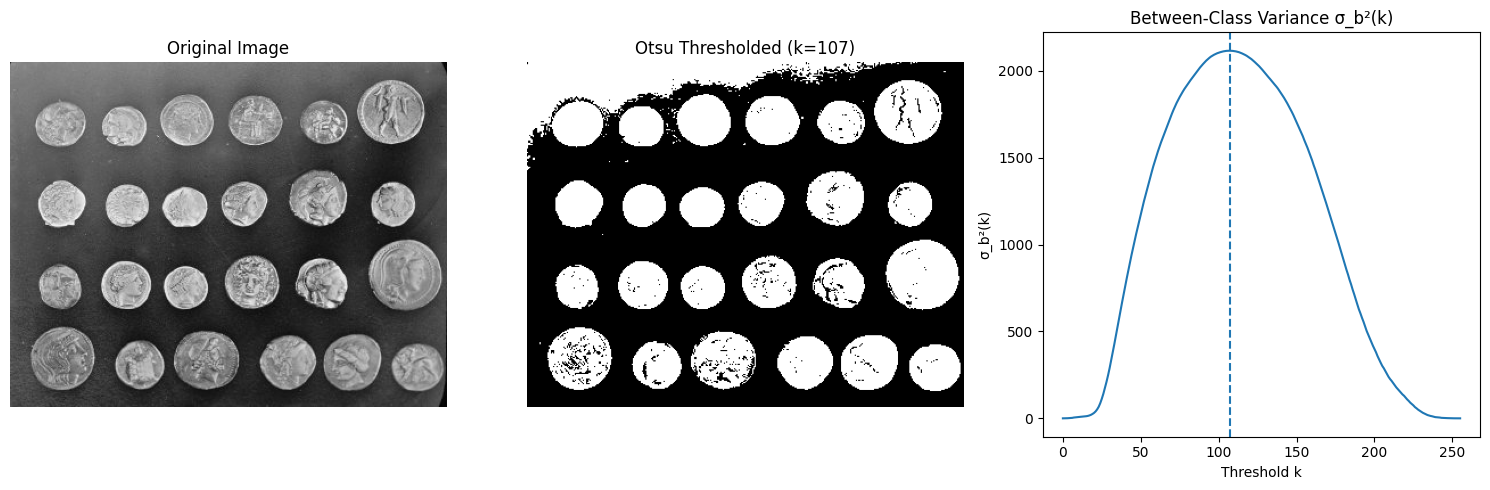

Optimal threshold (direct formula): 107


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage import img_as_ubyte

def otsu_threshold_direct(image):
    # Compute normalized histogram p[i]
    hist, _ = np.histogram(image.flatten(), bins=256, range=(0, 256))
    p = hist / image.size

    # Precompute cumulative sums for P(C1) and sum(i * P(i))
    cumulative_p = np.cumsum(p)                    # ω1(k)
    cumulative_ip = np.cumsum(p * np.arange(256))  # Σ_{i=0..k} i·P(i)
    mu_t = cumulative_ip[-1]                       # total mean Σ i·P(i)

    best_k = 0
    best_var = 0
    variances = np.zeros(256)

    # Loop over all thresholds k
    for k in range(256):
        ω1 = cumulative_p[k]        # P(C1)
        ω2 = 1.0 - ω1               # P(C2)
        if ω1 == 0 or ω2 == 0:
            variances[k] = 0
            continue

        # Class means:
        m1 = cumulative_ip[k] / ω1
        m2 = (mu_t - cumulative_ip[k]) / ω2

        # Direct between-class variance:
        σ_b2 = ω1 * ω2 * (m1 - m2)**2
        variances[k] = σ_b2

        if σ_b2 > best_var:
            best_var = σ_b2
            best_k = k

    return best_k, variances

# Load example grayscale image
image = img_as_ubyte(data.coins())

# Compute threshold and variances
threshold, variances = otsu_threshold_direct(image)

# Create binary image
binary = (image > threshold).astype(np.uint8) * 255

# Display results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(image, cmap='gray')
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(binary, cmap='gray')
axes[1].set_title(f"Otsu Thresholded (k={threshold})")
axes[1].axis('off')

axes[2].plot(variances)
axes[2].axvline(threshold, linestyle='--')
axes[2].set_title("Between-Class Variance σ_b²(k)")
axes[2].set_xlabel("Threshold k")
axes[2].set_ylabel("σ_b²(k)")

plt.tight_layout()
plt.show()

print(f"Optimal threshold (direct formula): {threshold}")


#ΑΣΚΗΣΗ


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
from skimage import img_as_ubyte

# Reuse otsu implementation
def otsu_threshold_direct(image):
    hist, _ = np.histogram(image.flatten(), bins=256, range=(0, 256))
    p = hist / image.size
    cumulative_p = np.cumsum(p)
    cumulative_ip = np.cumsum(p * np.arange(256))
    mu_t = cumulative_ip[-1]
    best_var = 0.0
    best_k = 0
    for k in range(256):
        ω1 = cumulative_p[k]
        ω2 = 1.0 - ω1
        if ω1 == 0 or ω2 == 0:
            continue
        m1 = cumulative_ip[k] / ω1
        m2 = (mu_t - cumulative_ip[k]) / ω2
        σ_b2 = ω1 * ω2 * (m1 - m2) ** 2
        if σ_b2 > best_var:
            best_var = σ_b2
            best_k = k
    return best_k

# Part 3: performance timing
sizes = [256, 512, 1024, 2048]
times = []

for s in sizes:
    # Generate a random grayscale image of size s x s
    img = np.random.randint(0, 256, size=(s, s), dtype=np.uint8)
    start = time.perf_counter()
    _ = otsu_threshold_direct(img)
    end = time.perf_counter()
    times.append(end - start)

# Display results
import pandas as pd
df = pd.DataFrame({"Side length": sizes, "Time (s)": times})
df

# Plotting
plt.figure()
plt.plot(sizes, times, marker='o')
plt.xlabel("Image side length (pixels)")
plt.ylabel("Execution time (seconds)")
plt.title("Otsu Thresholding Time Complexity")
plt.grid(True)
plt.show()
